In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/raw/bank-additional.csv", sep=";")

In [4]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4114,30,admin.,married,basic.6y,no,yes,yes,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.958,5228.1,no
4115,39,admin.,married,high.school,no,yes,no,telephone,jul,fri,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.959,5228.1,no
4116,27,student,single,high.school,no,no,no,cellular,may,mon,...,2,999,1,failure,-1.8,92.893,-46.2,1.354,5099.1,no
4117,58,admin.,married,high.school,no,no,no,cellular,aug,fri,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no


In [6]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [8]:
# Vérification de la structure, des types de variables et de la présence de valeurs manquantes
#Le jeu de données contient 4 119 observations et 21 variables. 
#Aucune valeur manquante n'est détectée.
#les valeurs "unknown" seront néanmoins vérifiées séparément
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   float64
 18 

In [9]:
# Vérification du nombre de valeurs "unknown" par variable
#nous avons un nombre important de modalités "unknown" concernant 4 variable
(df == "unknown").sum()

age                 0
job                39
marital            11
education         167
default           803
housing           105
loan              105
contact             0
month               0
day_of_week         0
duration            0
campaign            0
pdays               0
previous            0
poutcome            0
emp.var.rate        0
cons.price.idx      0
cons.conf.idx       0
euribor3m           0
nr.employed         0
y                   0
dtype: int64

In [10]:
# ici, on cherche à connaitre la répartition de la variable cible selon les modalités de default
pd.crosstab(df["default"], df["y"], normalize="index") * 100

y,no,yes
default,,
no,87.873303,12.126697
unknown,93.897883,6.102117
yes,100.000000,0.000000


In [11]:
# Pourcentage de valeurs "unknown" par variable
unknown_pct = (df == "unknown").mean() * 100
unknown_pct[unknown_pct > 0].sort_values(ascending=False)

default      19.495023
education     4.054382
housing       2.549162
loan          2.549162
job           0.946832
marital       0.267055
dtype: float64

In [12]:
df["y"].value_counts()

y
no     3668
yes     451
Name: count, dtype: int64

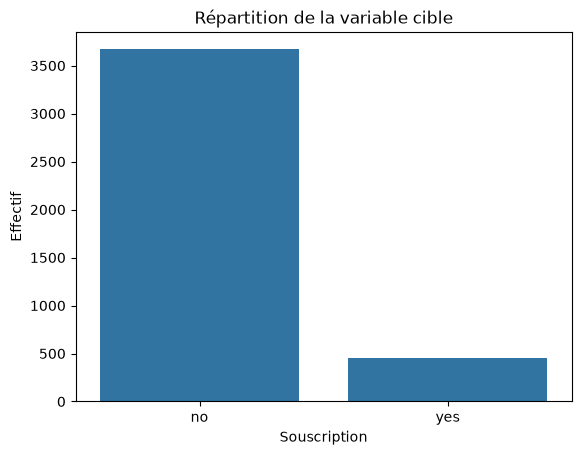

In [13]:
# Distribution de la variable cible
#La variable cible y présente un déséquilibre important entre ses deux modalités. La modalité no est largement majoritaire avec 3 668 observations, soit environ 89,1 % de l'échantillon, tandis que la modalité yes ne représente que 451 observations, soit environ 10,9 %. La population étudiée est donc majoritairement constituée d'individus n'ayant pas souscrit à l'offre. Ce déséquilibre devra être pris en compte lors de la modélisation et de l'évaluation des performances du modèle.
sns.countplot(data=df, x="y")
plt.title("Répartition de la variable cible")
plt.xlabel("Souscription")
plt.ylabel("Effectif")
plt.show()

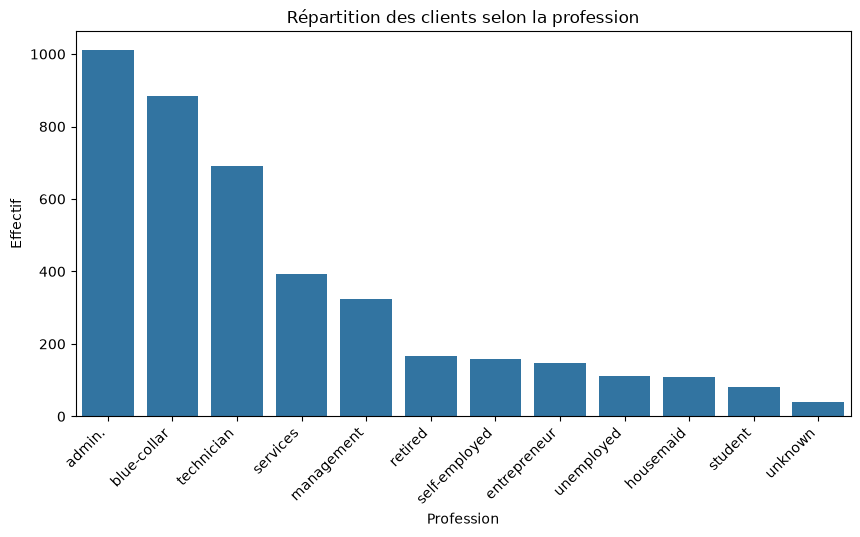

In [14]:
# Répartition des clients selon la profession
#Observation : La population est principalement composée de travailleurs et de personnes appartenant aux catégories de professions de bureau (`white_collar`). À l’inverse, les travailleurs indépendants (`self_employed`), les personnes inactives (`inactive`), les chômeurs (`unemployed`) et les autres profils (`other`) sont moins représentés. La population étudiée s’organise donc principalement autour de deux grands ensembles socioprofessionnels.
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="job", order=df["job"].value_counts().index)
plt.title("Répartition des clients selon la profession")
plt.xlabel("Profession")
plt.ylabel("Effectif")
plt.xticks(rotation=45, ha="right")
plt.show()

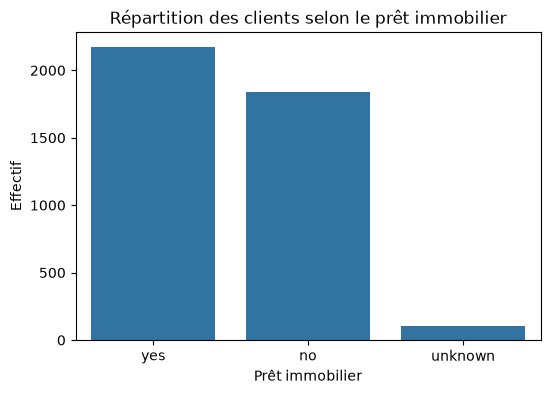

In [15]:
# Répartition des clients selon le prêt immobilier
#Les clients ayant un prêt immobilier sont légèrement plus nombreux que ceux n'en ayant pas. Les deux catégories restent toutefois bien représentées dans la population.
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="housing", order=df["housing"].value_counts().index)
plt.title("Répartition des clients selon le prêt immobilier")
plt.xlabel("Prêt immobilier")
plt.ylabel("Effectif")
plt.show()

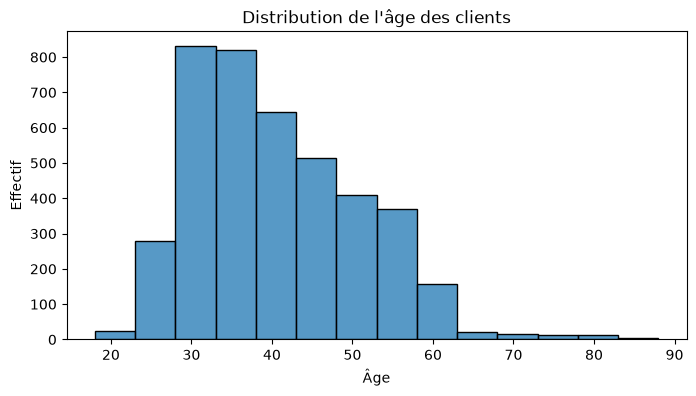

In [16]:
# Distribution de l'âge des clients
#La population est principalement concentrée entre 30 et 50 ans. Les individus les plus jeunes et les plus âgés sont moins représentés. Cette distribution permettra ensuite de justifier la création de classes d'âge pour certaines analyses.
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="age", binwidth=5)
plt.title("Distribution de l'âge des clients")
plt.xlabel("Âge")
plt.ylabel("Effectif")
plt.show()

In [17]:
# Proportion de souscription selon la profession
job_y_pct = pd.crosstab(
    df["job"],
    df["y"],
    normalize="index"
) * 100

job_y_pct

y,no,yes
job,,
admin.,86.857708,13.142292
blue-collar,93.099548,6.900452
entrepreneur,94.594595,5.405405
housemaid,90.000000,10.000000
management,90.740741,9.259259
retired,77.108434,22.891566
self-employed,91.823899,8.176101
services,91.094148,8.905852
student,76.829268,23.170732


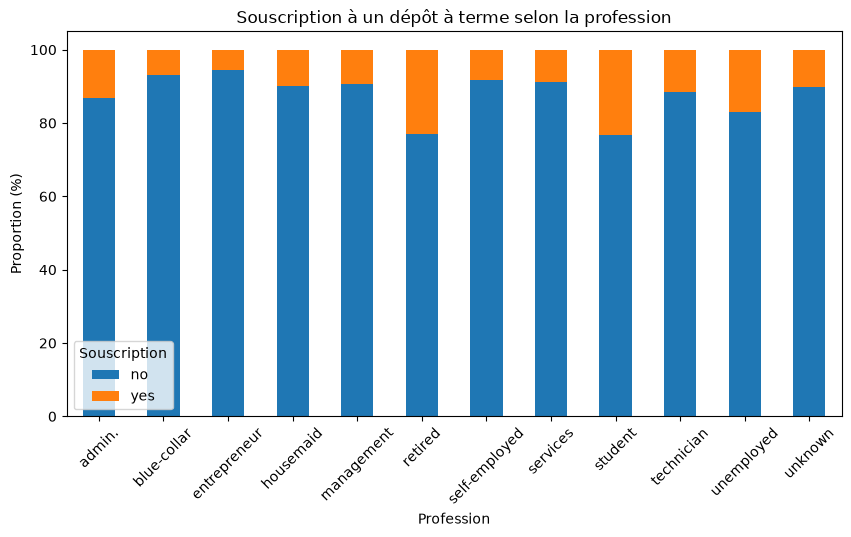

In [18]:
# Souscription selon la profession
#La proportion de souscription varie selon la profession, même si la réponse négative reste majoritaire dans toutes les catégories. Les personnes inactives et les chômeurs présentent une proportion de souscription relativement plus élevée, tandis que les travailleurs indépendants et les ouvriers semblent moins souvent répondre favorablement à l'offre.
job_y_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.title("Souscription à un dépôt à terme selon la profession")
plt.xlabel("Profession")
plt.ylabel("Proportion (%)")
plt.legend(title="Souscription")
plt.xticks(rotation=45)
plt.show()

In [19]:
# Création des classes d'âge
df["age_classe"] = pd.cut(
    df["age"],
    bins=[18, 30, 45, float("inf")],
    right=False,
    labels=["18-29 ans", "30-44 ans", "45 ans et plus"]
)

In [20]:
# Proportion de souscription selon la classe d'âge
age_y_pct = pd.crosstab(
    df["age_classe"],
    df["y"],
    normalize="index"
) * 100

age_y_pct

y,no,yes
age_classe,,
18-29 ans,87.840290,12.159710
30-44 ans,90.332594,9.667406
45 ans et plus,87.357197,12.642803


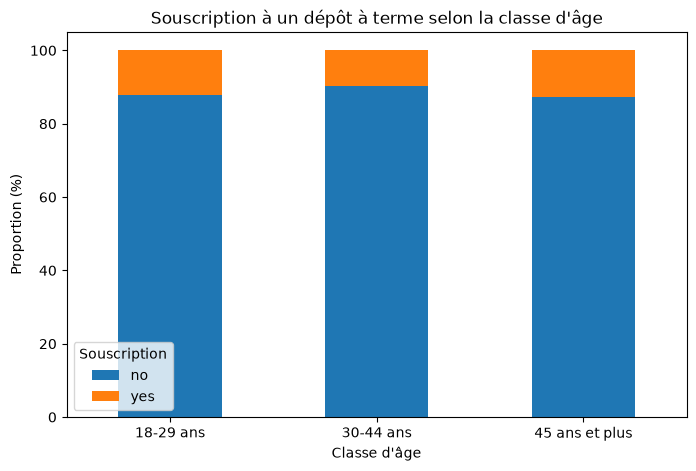

In [21]:
# Souscription selon la classe d'âge
age_y_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Souscription à un dépôt à terme selon la classe d'âge")
plt.xlabel("Classe d'âge")
plt.ylabel("Proportion (%)")
plt.legend(title="Souscription")
plt.xticks(rotation=0)
plt.show()